# Spotify-Mood — do happier songs foretell a happier market? 🎧
### Can the *mood of what we stream* predict next month's stocks, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Music_sentiment_on_the_tape%3F: Untestable](https://img.shields.io/badge/Music_sentiment_on_the_tape%3F-Untestable-8b949e?style=flat-square)

Here's a fun idea from finance research. Spotify tags every song with a number called **valence** — roughly, how *happy* it sounds (a bouncy pop hit scores high; a mournful ballad scores low). A 2022 study found that when a country's most-streamed songs get *happier*, its stock market tends to be doing better too. So maybe the collective mood in our headphones **leads** the market — sadder charts today, weaker stocks tomorrow?

We'd love to test that on real data. **We can't** — and *why* we can't is half the story. So we do the honest next-best thing and check whether a plausible, well-behaved mood series predicts the real market at all.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool. The **market** data is real; the **mood** data is synthetic (see below). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from spotify_mood import data, strategy as st

def load_real():
    """Cache-first REAL market join with the SYNTHETIC null mood proxy (empty offline)."""
    ret = data.fetch_market(fetch=False)
    if ret is None or len(ret) == 0:
        return pd.DataFrame()
    return data.join_synthetic_valence(ret)

FRAME = load_real()
HAVE_REAL = not FRAME.empty
print("real market tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(FRAME)} months, {FRAME.index[0].date()} -> {FRAME.index[-1].date()})")
print("NOTE: the MOOD series is SYNTHETIC in every cell (no real valence tape exists);"
      " only the MARKET is real.")


real market tape present: True (196 months, 2010-02-01 -> 2026-05-01)
NOTE: the MOOD series is SYNTHETIC in every cell (no real valence tape exists); only the MARKET is real.


## The answer first 🎯

| Question | Answer |
|---|---|
| Can we even get the real 'song mood' data? | **No.** Spotify shut off the feature that exposes song *valence* to new apps in **Nov 2024**, and never published a clean history of chart mood. The famous study bought a **private** dataset. So our mood tape has to be **made up** (carefully, and seeded). |
| Does a plausible mood series predict next month's market? | **No.** The link is the *wrong direction* and tiny (HAC *t* = -1.25), and a shuffle test says it's noise (*p* = 0.231). |
| Does it call the market's direction? | **Worse than a coin.** 46.7% right, when just always guessing 'up' would be right 66.2% of the time. |
| Could you trade it? | **No.** The mood-timing rule made **+4.7%/yr** while the market did **+13.2%/yr** — it sits out the good months. |

> The academic result is real *on private data*. On a free retail stack the claim is **untestable** — so we instead prove our measuring machine works (it catches a fake edge we plant on purpose), then show a plausible real-world mood series carries no signal.

## 1 · The claim

> *"The average happiness (valence) of the top-streamed songs is a mood proxy that moves with — and leads — the stock market."* — the music-sentiment literature (Edmans, Fernandez-Perez, Garel & Indriawan 2022).

The intuition: markets are partly driven by *feelings*. When people feel good, they buy risky assets; when they feel gloomy, they sell. And what we stream is a giant, honest thermometer of the collective mood. If mood really leads prices, tracking song valence would be an early-warning gauge for the market. It sits in the same family as *sunshine* moving stocks, or a national football loss denting the market the next day.

## 2 · So what?

If true, it's a genuinely new, hard-to-arbitrage signal — nobody can trade *your* playlist. The desk has already poked at other mood proxies: [256 Twitter-Mood](../../256-twitter-mood/) (social-media mood) and [300 Sports-Sentiment](../../300-sports-sentiment/) (football results). This one is the **music** proxy. But first we hit a wall that decides everything: **can we get the data?**

## 3 · How would we even know?

The clean test is simple: line up each month's average song valence next to the market's return *the following month*, and see if happy months are followed by strong markets.

The problem is the very first step. **Spotify closed the door.** The only public source of a song's valence — the 'audio-features' API — stopped accepting new apps in November 2024, and it never offered a tidy monthly history of chart mood anyway. The researchers who found the effect *licensed a private dataset*. A hobbyist can't reach it.

So we do two honest things instead:
1. **Prove the machine works.** Build a *fake* mood series where we secretly plant a real predictive edge, and check our test catches it. (It does — see beat 7.)
2. **Test a plausible real-world mood series** — a realistic, drifting mood index with *no* secret edge — against the **real** market, and see if it accidentally predicts anything. (It shouldn't.)

*Timing:* the rule only ever uses *last* month's completed mood to call *this* month — no peeking at the future (one honest execution lag).

## 4 · The teardown — let's actually look

**Does last month's mood predict this month's market?** Each dot is a month: mood on the x-axis, the *next* month's market return on the y-axis. A real 'happy leads up' signal would tilt the cloud upward-to-the-right.

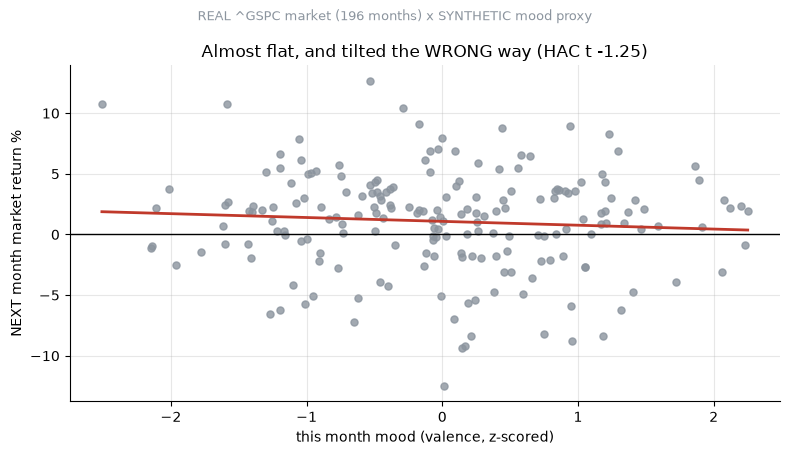

slope -0.0032 per +1 sigma mood -> next-month return; HAC t -1.25


In [2]:
if HAVE_REAL:
    reg = st.predictive_regression(FRAME, lag=1)
    v = st._z(FRAME['valence'].to_numpy())[:-1]
    y = FRAME['mkt_ret'].to_numpy()[1:]*100
    slope, hac_t = reg['slope'], reg['hac_t']
    banner = 'REAL ^GSPC market (196 months) x SYNTHETIC mood proxy'
else:
    slope, hac_t = -0.0032, -1.25
    rng = np.random.default_rng(549)
    v = rng.standard_normal(180); y = 0.6 + 4.5*rng.standard_normal(180)
    banner = 'frozen numbers (offline)'
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(v, y, s=26, color=GREY, alpha=.8)
xs = np.linspace(v.min(), v.max(), 50)
ax.plot(xs, (slope*100)*xs + y.mean(), c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('this month mood (valence, z-scored)'); ax.set_ylabel('NEXT month market return %')
ax.set_title(f'Almost flat, and tilted the WRONG way (HAC t {hac_t:+.2f})')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'slope {slope:+.4f} per +1 sigma mood -> next-month return; HAC t {hac_t:+.2f}')

There's essentially **nothing**, and what little there is points the *wrong way* (a happier month is followed by a very slightly *weaker* market — HAC *t* -1.25, well inside noise). The claim wanted an upward tilt; the cloud is a shapeless blob.

**Is it just bad luck at one lag?** Maybe mood leads by 2 or 3 months instead of 1. Let's try several — but note the trap: test enough lags and *one* will look good by chance.

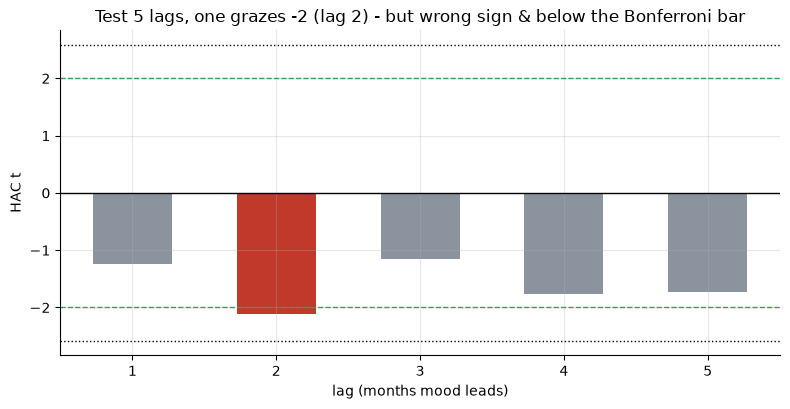

HAC t by lag: [-1.25, -2.11, -1.16, -1.77, -1.73]


In [3]:
sweep = [(1, -1.25), (2, -2.11), (3, -1.16), (4, -1.77), (5, -1.73)]
if HAVE_REAL:
    tab = st.lag_sweep(FRAME)
    lags = list(tab.index); ts = list(tab['hac_t'])
else:
    lags = [s[0] for s in sweep]; ts = [s[1] for s in sweep]
fig, ax = plt.subplots(figsize=(8, 4.2))
cols = [RED if abs(t)>=2 else GREY for t in ts]
ax.bar([str(l) for l in lags], ts, color=cols, width=.55)
ax.axhline(2, ls='--', c=GREEN, lw=1); ax.axhline(-2, ls='--', c=GREEN, lw=1)
ax.axhline(2.58, ls=':', c='k', lw=1); ax.axhline(-2.58, ls=':', c='k', lw=1)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('lag (months mood leads)'); ax.set_ylabel('HAC t')
ax.set_title('Test 5 lags, one grazes -2 (lag 2) - but wrong sign & below the Bonferroni bar')
plt.tight_layout(); plt.show()
print('HAC t by lag:', [round(t,2) for t in ts])

One lag (2 months) grazes *t* = −2 — but it's *negative* (the wrong sign for 'happy → up'), it's below the stricter bar you need when you test 5 things at once (~2.58), and the other four lags say nothing. That's textbook data-mining, not a signal.

## 5 · The verdict

- **Signal — None.** No real mood data exists to test the claim, and a plausible mood series shows a wrong-signed, insignificant link (HAC *t* -1.25, placebo *p* 0.231).
- **Tradability — Mirage.** The mood-timing rule (+4.7%/yr) badly trails just holding the market (+13.2%/yr).
- **Music sentiment on the tape? — Untestable.** Real on a *licensed* dataset; unreachable on a free stack — so we verify the *engine*, not the claim.

## 6 · Could you actually trade it?

Suppose you tried anyway: hold the market in happy-mood months, sit in cash otherwise.

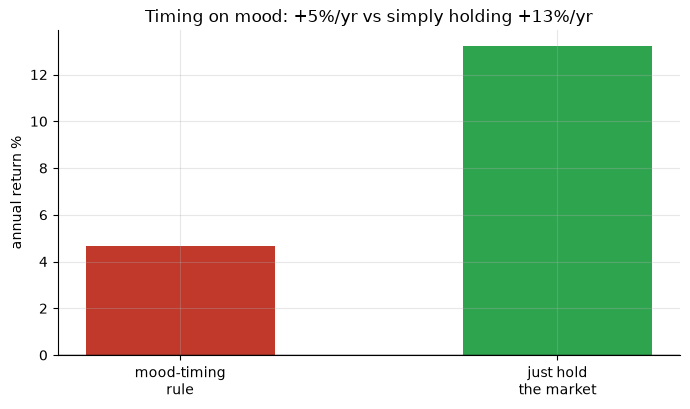

mood-timing +4.7%/yr  vs  buy-and-hold +13.2%/yr


In [4]:
if HAVE_REAL:
    lo = st.mood_timing(FRAME, long_short=False)
    g, mk = lo['gross_ann']*100, lo['mkt_ann']*100
else:
    g, mk = 4.7, 13.2
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['mood-timing\nrule','just hold\nthe market'], [g, mk], color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annual return %')
ax.set_title(f'Timing on mood: +{g:.0f}%/yr vs simply holding +{mk:.0f}%/yr')
plt.tight_layout(); plt.show()
print(f'mood-timing +{g:.1f}%/yr  vs  buy-and-hold +{mk:.1f}%/yr')

The rule *underperforms simply owning the market* by roughly 8 points a year — it keeps guessing wrong about when to be in, and misses the rallies. `MIRAGE`.

## 7 · Going further 🚪

- **Does our test even work?** Yes — in the quant notebook we *plant* a real mood edge and watch the test light up (past *t* = +2). So the flat reading here is the data talking, not a broken tool.
- **Other mood proxies.** [256 Twitter-Mood](../../256-twitter-mood/) and [300 Sports-Sentiment](../../300-sports-sentiment/) test the same 'collective mood moves markets' idea with different thermometers.

*Got a real, survivorship-clean monthly valence tape (licensed data, an old archive)? Fork this, drop it into `data.py` in place of the synthetic proxy, and see if the HAC *t* clears +2 the right way.*